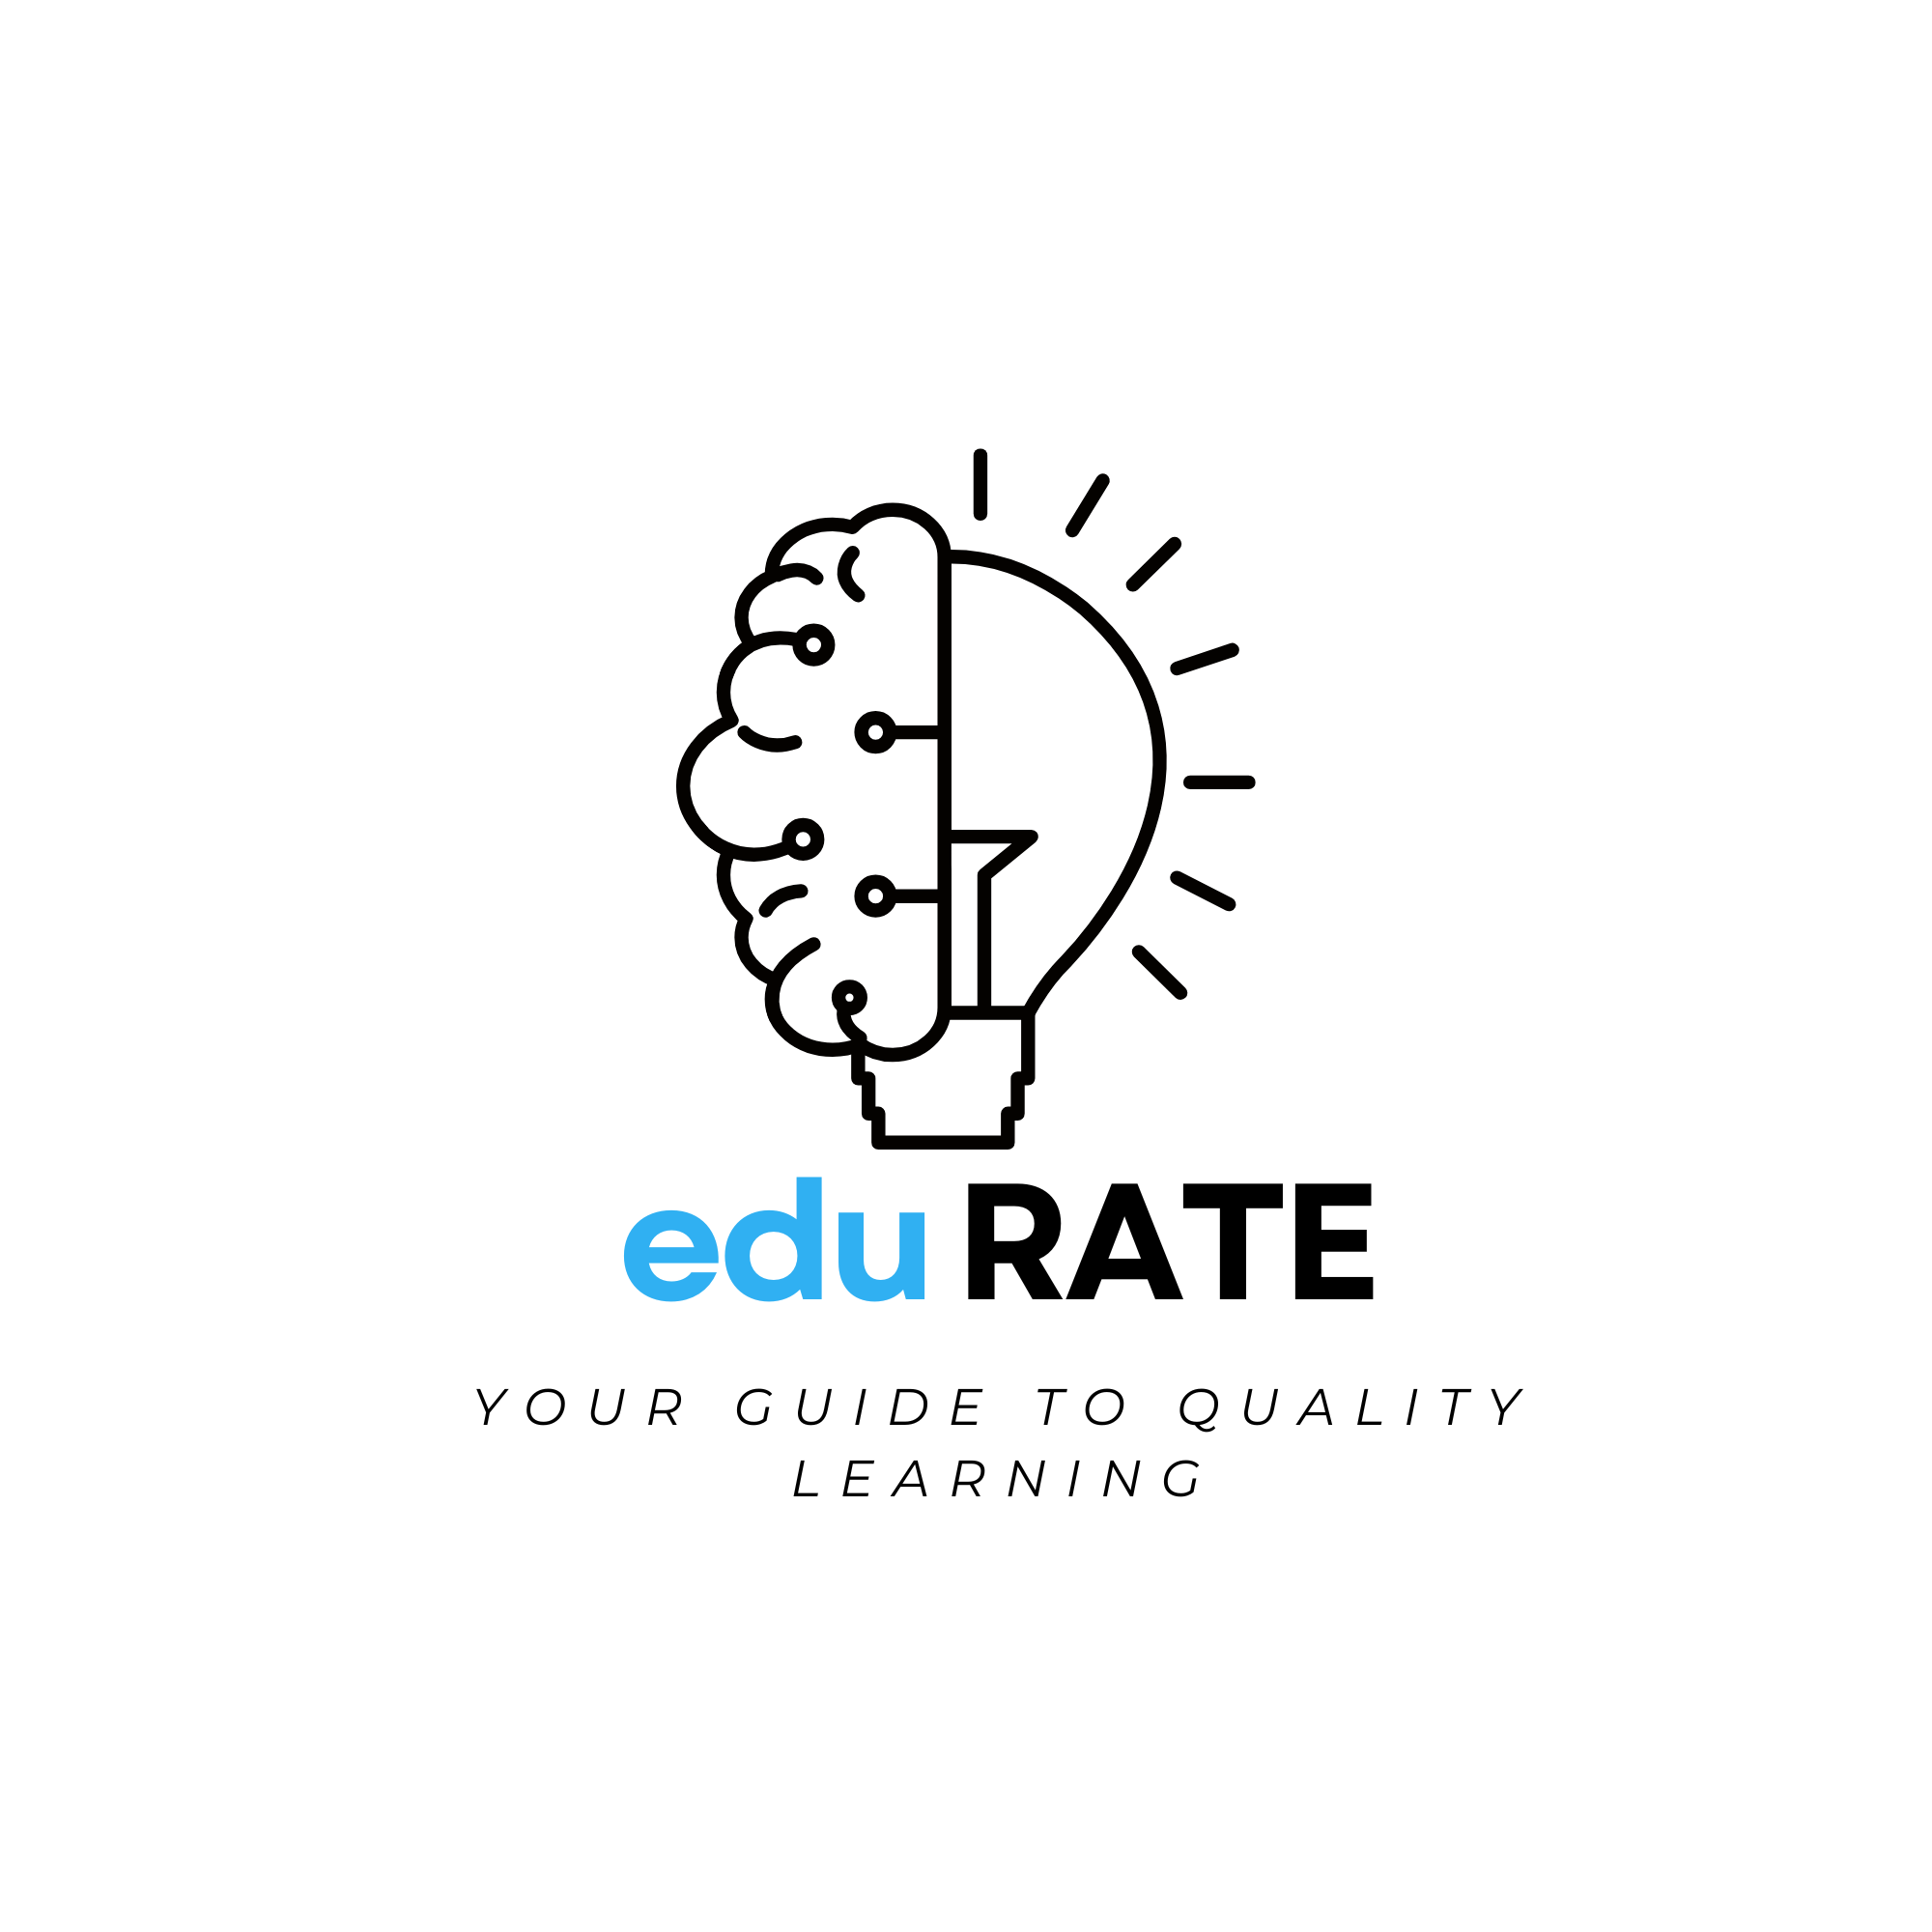

**Review Filtering Feature**

In [ ]:
'''
Description For This Feature:
This notebook is for developing the review filtering feature for edu Rate project
Review filtering feature will help to make sure that whatever is posted is an appropriate, relevant and safe review that will be displayed on the platform. The system accepts the review text posted by the user and processes the input to identify abusive language, spam or inappropriate material through text classification methods. The result of this process is a decision that the review should be accepted, rejected or moderated. This feature is critical in ensuring a reliable and professional site, particularly because reviews are done anonymously. The system should be automated and effective when submitting a review, so that malicious or deceptive material is not shown. This will make the platform more reliable and credible since it will only have meaningful and respectful feedback that users can access.
'''

'\nDescription For This Feature:\nThis notebook is for developing the review filtering feature for edu Rate project\nReview filtering feature will help to make sure that whatever is posted is an appropriate, relevant and safe review that will be displayed on the platform. The system accepts the review text posted by the user and processes the input to identify abusive language, spam or inappropriate material through text classification methods. The result of this process is a decision that the review should be accepted, rejected or moderated. This feature is critical in ensuring a reliable and professional site, particularly because reviews are done anonymously. The system should be automated and effective when submitting a review, so that malicious or deceptive material is not shown. This will make the platform more reliable and credible since it will only have meaningful and respectful feedback that users can access.\n'

# Importing Neccessary Libraries

In [ ]:
# Libraries For Data Handling
import pandas as pd
import numpy as np
# Libraries For Data Visualization
import matplotlib.pyplot as plt
# Libraries For NLP Processing
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# Libraires For ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
# Libraries To Save The Models For Deployment Purposes And Later Use
import pickle
# Other Libraries
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments
)
import torch

In [ ]:
# Onetime Setup For Donwnloading Needed Packages
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

# Data Collection

In [ ]:
# Data Augmentation Technique For handling Data Imbalance
import pandas as pd
import random
# Toxic sentence templates
toxic_templates = [
    "You are {insult}.",
    "The seller is {insult}.",
    "These people are {insult}.",
    "Only {insult} people buy this.",
    "You are so {insult}.",
    "The people selling this are {insult}.",
    "Shut up, you {insult}.",
    "Nobody likes you, you {insult}.",
    "This seller is completely {insult}.",
    "You sound {insult}.",
    "Anyone buying this is {insult}.",
    "You are acting like a {insult}.",
    "This company is run by {insult} people.",
    "You are absolutely {insult}.",
    "People like you are {insult}.",
]
# Toxic words
insults = [
    "stupid",
    "useless",
    "idiotic",
    "dumb",
    "foolish",
    "disgusting",
    "trash",
    "garbage",
    "annoying",
    "pathetic",
    "moronic",
    "brain dead",
    "clueless",
    "worthless",
    "awful",
    "terrible",
    "ridiculous",
    "embarrassing",
    "ignorant",
    "crazy"
]
# Variations function
def generate_variations(sentence):
    variations = []
    variations.append(sentence)
    variations.append(sentence.lower())
    variations.append(sentence.upper())
    variations.append(sentence.replace(".", "!!!"))
    variations.append(sentence.replace("You are", "You're"))
    variations.append(sentence.replace("you", "u"))
    variations.append(sentence.replace("people", "ppl"))
    return list(set(variations))
# Generate toxic examples
augmented_toxic = []
for template in toxic_templates:
    for insult in insults:
        sentence = template.format(insult=insult)
        variations = generate_variations(sentence)
        augmented_toxic.extend(variations)
# Remove duplicates
augmented_toxic = list(set(augmented_toxic))
# Create dataframe of the examples
toxic_df = pd.DataFrame({
    "text": augmented_toxic,
    "label": [1] * len(augmented_toxic)
})
# Shuffle
toxic_df = toxic_df.sample(frac=1, random_state=42).reset_index(drop=True)
# Check the size of the examples
print("Generated toxic examples:", len(toxic_df))
# Preview the examples
print(toxic_df.head(20))

Generated toxic examples: 1420
                                    text  label
0               Shut up, you ridiculous.      1
1                          YOU ARE DUMB.      1
2          Only foolish people buy this.      1
3                 you are so brain dead.      1
4                      YOU ARE SO TRASH.      1
5      The ppl selling this are garbage.      1
6                     You are so stupid.      1
7           You're absolutely worthless.      1
8                The seller is clueless.      1
9                       You are idiotic.      1
10                Shut up, u disgusting.      1
11        Anyone buying this is idiotic.      1
12  the people selling this are garbage.      1
13               THESE PEOPLE ARE TRASH.      1
14                    You are so dumb!!!      1
15    THIS SELLER IS COMPLETELY FOOLISH.      1
16      You are absolutely disgusting!!!      1
17         PEOPLE LIKE YOU ARE ANNOYING.      1
18                   Shut up, you awful.      1
19    the

In [ ]:
# Reading the dataset and print the five records of the dataset
df = pd.read_csv('/content/FinalBalancedDataset.csv')
df.head()
print(df["Toxicity"].value_counts())

Toxicity
0    32592
1    24153
Name: count, dtype: int64


In [ ]:
# Remove the unneeded columns + merge the generated examples with the dataset
df = df.drop(columns=["Unnamed: 0"], errors="ignore")
toxic_df = toxic_df.rename(columns={
    "text": "tweet",
    "label": "Toxicity"
})
df = pd.concat([df, toxic_df], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
print(df.head())
print(df["Toxicity"].value_counts())

   Toxicity                                              tweet
0         1  #sikh #temple vandalised in in #calgary, #wso ...
1         0  i was in rome a year ago today...and now i'm s...
2         0  wow, wow, wow. my create a plan for your life ...
3         1  Niggas/bitches cheat cause mf's always think t...
4         0  my promise!!!ð look different today!! #self...
Toxicity
0    32592
1    25573
Name: count, dtype: int64


# Exploratory Data Analysis (EDA)

In [ ]:
# Check for the first 10 records from the dataset
df.head(10)

,Toxicity,tweet
0,1,"#sikh #temple vandalised in in #calgary, #wso ..."
1,0,i was in rome a year ago today...and now i'm s...
2,0,"wow, wow, wow. my create a plan for your life ..."
3,1,Niggas/bitches cheat cause mf's always think t...
4,0,my promise!!!ð look different today!! #self...
5,0,tribute tho . a composition made in favour of...
6,0,@user poor little one ðª
7,1,@user @user @user because trump is a #fascist ...
8,0,@user one of my favs #flashbackfriday #girlsp...
9,0,@user Â°ð¹ð¿ð¹ð¿ð¹ð¿ð¹ð¿ð¹ð...


In [ ]:
# Check for the last 10 records from the dataset
df.tail(10)

,Toxicity,tweet
58155,0,"the most cheesiest picture ever, but i love it..."
58156,0,jst the past few weeks a close family frnd was...
58157,0,Wicked Oreo
58158,0,from #bracelet #vintagestyle w/free #butterfl...
58159,1,"Marijuana, hydro, pussy hoe, ass titties"
58160,1,Ummm...so the Happy Fairy apparently took a cr...
58161,1,@ivanrabago_ at least put a caption when steal...
58162,1,black professor makes assumptions about an ent...
58163,0,#lgbtqhatetrumppay is total #liberal trash. it...
58164,1,sorry wrong bitch &#9996;&#65039;


In [ ]:
# Check for the format of the columns
df.dtypes

,0
Toxicity,int64
tweet,object


In [ ]:
# Check for the name of the existed columns
df.columns

Index(['Toxicity', 'tweet'], dtype='object')

In [ ]:
# Check for the size of the dataset
df.shape

(58165, 2)

In [ ]:
# Check for general information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58165 entries, 0 to 58164
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Toxicity  58165 non-null  int64 
 1   tweet     58165 non-null  object
dtypes: int64(1), object(1)
memory usage: 909.0+ KB


In [ ]:
# Check the missing data
missing_data = df.isnull().sum()
print(missing_data)

Toxicity    0
tweet       0
dtype: int64


In [ ]:
# Check the duplicated data
duplicated_data = df.duplicated().sum()
print(duplicated_data)

2432


In [ ]:
# Drop the duplicated data
#df = df.drop_duplicates()
# Check the duplication
#print(df.duplicated().sum())

0


In [ ]:
# Check for the distribution of the data
df['Toxicity'].value_counts().sort_index()

,count
Toxicity,
0,32592
1,25573


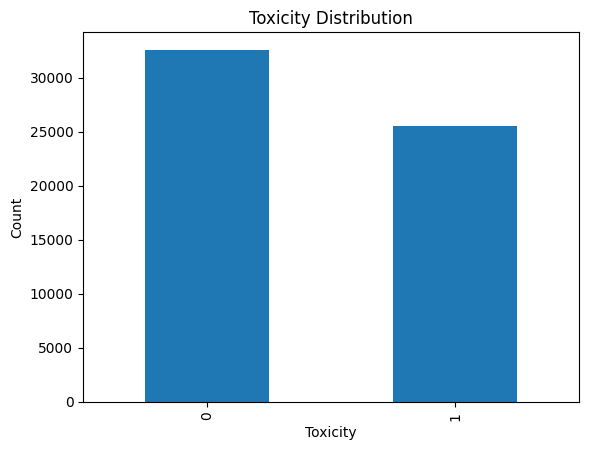

In [ ]:
# a Visual for the distibution of the label column
df['Toxicity'].value_counts().sort_index().plot(kind='bar')
plt.title("Toxicity Distribution")
plt.xlabel("Toxicity")
plt.ylabel("Count")
plt.show()

# Data Processing

In [ ]:
# Cleaning text function
def cleaning_textReviews(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [ ]:
# Apply the cleaning text function
df['clean_text_review'] = df['tweet'].apply(cleaning_textReviews)

# Model Development

In [ ]:
# Split the dataset for feature and label
x = df['clean_text_review']
y = df['Toxicity']

In [ ]:
# Split for training and testing
x_train, x_test, y_train, y_test = train_test_split (x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Load the bert pre-trained model
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

In [ ]:
# Now we will use Bert Model for tokenization and model training
tokenized_train = tokenizer(list(x_train), truncation=True, padding=True, max_length=128)
tokenized_test = tokenizer(list(x_test), truncation=True, padding=True, max_length=128)

In [ ]:
# Now we will build a custom dataset for the model training
class training_sentiment_data(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item
    def __len__(self):
        return len(self.labels)

In [ ]:
# Creating an instance from the custom dataset
training_dataset = training_sentiment_data(tokenized_train, y_train)
testing_dataset = training_sentiment_data(tokenized_test, y_test)

In [ ]:
# Now after data embedding and representation using bert, now we need to start with loading bert model for classification
model = BertForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Configure the training arguments
training_confg = TrainingArguments(
    output_dir="./results",
    num_train_epochs=4,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    warmup_ratio=0.1,
    weight_decay=0.01,
    logging_dir="./logs",
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    save_total_limit=2
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
# Metrics function for the f1-score
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions)
    return {
        "accuracy": accuracy,
        "f1": f1,
    }
# Trainer hyperparameters
trainer = Trainer(
    model=model,
    args=training_confg,
    train_dataset=training_dataset,
    eval_dataset=testing_dataset,
    compute_metrics=compute_metrics
)

In [ ]:
# Start the training
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.059010,0.202656,0.954526,0.948626
2,0.116681,0.159171,0.959856,0.954058
3,0.038830,0.199937,0.961833,0.956265
4,0.034062,0.284928,0.960199,0.954710


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=11636, training_loss=0.050567595680744024, metrics={'train_runtime': 4613.5118, 'train_samples_per_second': 40.344, 'train_steps_per_second': 2.522, 'total_flos': 1.224308362801152e+16, 'train_loss': 0.050567595680744024, 'epoch': 4.0})

# Model Evaluation

In [ ]:
# Evaluate the performance of the model
prediction = trainer.predict(testing_dataset)
y_predict = np.argmax(prediction.predictions, axis=1)
print("The accuracy is: ", accuracy_score(y_test, y_predict))
print(classification_report(y_test, y_predict))

The accuracy is:  0.9617467549213444
              precision    recall  f1-score   support

           0       0.96      0.97      0.97      6518
           1       0.96      0.95      0.96      5115

    accuracy                           0.96     11633
   macro avg       0.96      0.96      0.96     11633
weighted avg       0.96      0.96      0.96     11633



# Save the model

In [ ]:
# Save the model and the tokenizer
trainer.save_model("./filtering_bert_model3")
tokenizer.save_pretrained("./filtering_bert_model3")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./filtering_bert_model3/tokenizer_config.json',
 './filtering_bert_model3/tokenizer.json')

In [ ]:
import shutil

shutil.make_archive("filtering_bert_model3", 'zip', "./filtering_bert_model3")

'/content/filtering_bert_model3.zip'

In [ ]:
from google.colab import files

files.download("filtering_bert_model3.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install transformers

In [1]:
!unzip filtering_bert_model3.zip

Archive:  filtering_bert_model3.zip
  inflating: tokenizer_config.json   
  inflating: model.safetensors       
  inflating: training_args.bin       
  inflating: config.json             
  inflating: tokenizer.json          


In [ ]:
import os

print(os.listdir())

['.config', '.ipynb_checkpoints', 'filtering_bert_model.zip', 'sample_data']


In [2]:
# load the saved model for testing
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
model_path = "./"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
model.eval()
print("Model loaded successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded successfully!


In [3]:
# Testing data
text = "you are stupid worthless idiot"
inputs = tokenizer(
    text,
    return_tensors="pt",
    truncation=True,
    padding=True
)
with torch.no_grad():
    outputs = model(**inputs)
prediction = torch.argmax(outputs.logits, dim=1)
print("Predicted class:", prediction.item())

Predicted class: 1


In [4]:
# Testing data
text1 = "good"
inputs = tokenizer(
    text1,
    return_tensors="pt",
    truncation=True,
    padding=True
)
with torch.no_grad():
    outputs = model(**inputs)
prediction = torch.argmax(outputs.logits, dim=1)
print("Predicted class:", prediction.item())

Predicted class: 0


In [5]:
# Testing data
import torch
text = "I hate these people."
inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
with torch.no_grad():
    outputs = model(**inputs)
probs = torch.softmax(outputs.logits, dim=1)
print("Logits:", outputs.logits)
print("Probabilities:", probs)
print("Predicted class:", torch.argmax(probs, dim=1).item())

Logits: tensor([[ 1.2059, -1.3638]])
Probabilities: tensor([[0.9289, 0.0711]])
Predicted class: 0


In [6]:
# Testing data
failed_cases = [
    "You are stupid and useless.",
    "This seller is an idiot.",
    "I hate these people.",
    "You are disgusting.",
    "Go away, nobody wants you here.",
    "This is trash and only dumb people buy it.",
    "You should be ashamed of yourself.",
    "The people selling this are garbage.",
    "Worst product ever, you idiots.",
    "Shut up, you fool."
]
for text in failed_cases:
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    probs = torch.softmax(outputs.logits, dim=1)[0]
    pred = torch.argmax(probs).item()
    print(text)
    print("Pred:", pred)
    print("Not toxic:", round(probs[0].item(), 4))
    print("Toxic:", round(probs[1].item(), 4))
    print("-" * 50)

You are stupid and useless.
Pred: 1
Not toxic: 0.0001
Toxic: 0.9999
--------------------------------------------------
This seller is an idiot.
Pred: 1
Not toxic: 0.0001
Toxic: 0.9999
--------------------------------------------------
I hate these people.
Pred: 0
Not toxic: 0.9289
Toxic: 0.0711
--------------------------------------------------
You are disgusting.
Pred: 1
Not toxic: 0.0001
Toxic: 0.9999
--------------------------------------------------
Go away, nobody wants you here.
Pred: 0
Not toxic: 0.9741
Toxic: 0.0259
--------------------------------------------------
This is trash and only dumb people buy it.
Pred: 1
Not toxic: 0.0001
Toxic: 0.9999
--------------------------------------------------
You should be ashamed of yourself.
Pred: 0
Not toxic: 0.9973
Toxic: 0.0027
--------------------------------------------------
The people selling this are garbage.
Pred: 1
Not toxic: 0.0001
Toxic: 0.9999
--------------------------------------------------
Worst product ever, you idiots.